In [1]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
from collections import defaultdict
import json
from torchvision.models.detection.retinanet import RetinaNet
from torchvision.models import *
import tensorflow_hub as hub
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.io.image import *
from torchvision.models.detection import retinanet_resnet50_fpn_v2, RetinaNet_ResNet50_FPN_V2_Weights
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import to_pil_image
plt.rcParams['figure.figsize'] = (15,15)
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.6/962.6 kB 12.1 MB/s eta 0:00:00


In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 46.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [3]:
from ultralytics import YOLO
import torch


model = YOLO('yolov8n.pt')

In [4]:
voc_root = "/content/VOC"
VOC_CLASSES = [
    'bus', 'person', 'sheep', 'car', 'bottle', 'aeroplane', 'boat', 'train',
    'pottedplant', 'cow', 'diningtable', 'sofa', 'horse', 'motorbike', 'bicycle',
    'chair', 'bird', 'dog', 'cat', 'tvmonitor'
]
class_to_idx = {cls: i + 1 for i, cls in enumerate(VOC_CLASSES)}
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Evaluation metric
metric = MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=True)

In [5]:
from torchvision.datasets import VOCDetection

In [6]:
def voc_transform(img, target):
    return img, target

# Load VOC validation dataset
dataset = VOCDetection(root=voc_root, year='2012', image_set='val', download=True, transforms=voc_transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

# Extract GT from VOC annotation
def extract_voc_targets(target):
    boxes = []
    labels = []
    obj_list = target['annotation'].get('object', [])
    if isinstance(obj_list, dict):
        obj_list = [obj_list]
    for obj in obj_list:
        cls_name = obj['name']
        if cls_name not in class_to_idx:
            continue
        bbox = obj['bndbox']
        xmin = float(bbox['xmin'])
        ymin = float(bbox['ymin'])
        xmax = float(bbox['xmax'])
        ymax = float(bbox['ymax'])
        boxes.append([xmin, ymin, xmax, ymax])
        labels.append(class_to_idx[cls_name])
    return boxes, labels

# Evaluation loop
for idx, (images, targets) in enumerate(dataloader):
    img_pil = images[0]  # YOLO accepts PIL directly
    gt_boxes, gt_labels = extract_voc_targets(targets[0])
    if len(gt_boxes) == 0:
        continue
    gt = [{
        "boxes": torch.tensor(gt_boxes),
        "labels": torch.tensor(gt_labels)
    }]

    # Run YOLO inference
    results = model(img_pil)[0]  # YOLO returns a list

    pred_boxes = []
    pred_scores = []
    pred_labels = []

    for box, score, label in zip(
        results.boxes.xyxy.cpu().numpy(),
        results.boxes.conf.cpu().numpy(),
        results.boxes.cls.cpu().numpy().astype(int)
    ):
        class_name = model.names[label]
        if class_name not in class_to_idx:
            continue  # skip classes not in VOC
        pred_boxes.append(torch.tensor(box))
        pred_scores.append(torch.tensor(score))
        pred_labels.append(torch.tensor(class_to_idx[class_name]))

    if len(pred_boxes) == 0:
        continue

    pred = [{
        "boxes": torch.stack(pred_boxes),
        "scores": torch.stack(pred_scores),
        "labels": torch.stack(pred_labels)
    }]

    metric.update(pred, gt)

    if idx % 100 == 0:
        print(f"Processed {idx} images")

# Final results
results = metric.compute()
print("\n📊 VOC-style mAP@0.5 Evaluation with YOLO:")
for k, v in results.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

100%|██████████| 2.00G/2.00G [01:03<00:00, 31.4MB/s]


Streaming output truncated to the last 5000 lines.
0: 448x640 1 chair, 1 couch, 1 book, 187.6ms
Speed: 4.2ms preprocess, 187.6ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 640x480 2 persons, 2 horses, 191.0ms
Speed: 6.6ms preprocess, 191.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)

0: 480x640 2 cats, 209.7ms
Speed: 4.9ms preprocess, 209.7ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

0: 640x448 1 cat, 178.1ms
Speed: 4.8ms preprocess, 178.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 448)

0: 448x640 1 car, 1 airplane, 177.2ms
Speed: 3.9ms preprocess, 177.2ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 480x640 2 cars, 206.5ms
Speed: 7.9ms preprocess, 206.5ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 dogs, 1 bowl, 1 chair, 1 couch, 190.1ms
Speed: 4.2ms preprocess, 190.1ms inference, 2.9ms postprocess per image at shape (1, 3, 480, 640)



In [7]:
import random

def show_random_yolo_prediction_on_voc(dataset, model, class_to_idx, score_thresh=0.3):
    idx_to_class = {v: k for k, v in class_to_idx.items()}
    index = random.randint(0, len(dataset) - 1)

    # Get image and target
    img_pil, target = dataset[index]

    # Get file name & ID
    image_id = target['annotation']['filename']

    # Run YOLO inference
    result = model(img_pil)[0]

    boxes = result.boxes.xyxy.cpu().numpy()
    scores = result.boxes.conf.cpu().numpy()
    labels = result.boxes.cls.cpu().numpy().astype(int)

    # Filter predictions to VOC classes
    filtered_boxes = []
    filtered_scores = []
    filtered_labels = []
    for box, score, label in zip(boxes, scores, labels):
        class_name = model.names[label]
        if class_name in class_to_idx and score >= score_thresh:
            filtered_boxes.append(box)
            filtered_scores.append(score)
            filtered_labels.append(class_name)

    # Plot image with predictions
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img_pil)
    for box, score, cls_name in zip(filtered_boxes, filtered_scores, filtered_labels):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 5, f"{cls_name} ({score:.2f})", color='lime', fontsize=12)

    plt.axis('off')
    plt.title(f"YOLO Prediction on VOC Image: {image_id}")
    plt.show()



0: 480x640 1 boat, 201.5ms
Speed: 4.7ms preprocess, 201.5ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


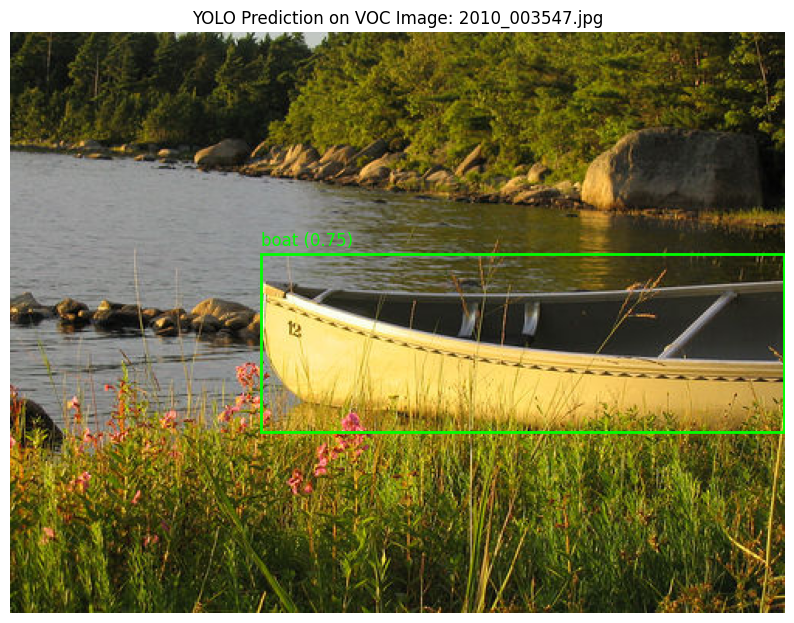

In [8]:
show_random_yolo_prediction_on_voc(dataset, model, class_to_idx)



0: 480x640 1 person, 1 bottle, 5 chairs, 1 potted plant, 1 microwave, 1 oven, 1 refrigerator, 184.5ms
Speed: 5.2ms preprocess, 184.5ms inference, 5.3ms postprocess per image at shape (1, 3, 480, 640)


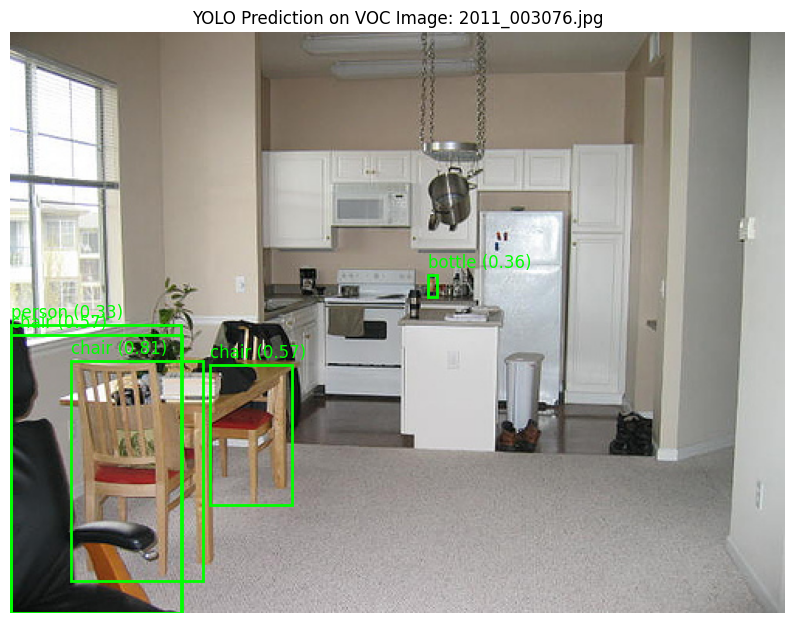

In [9]:
show_random_yolo_prediction_on_voc(dataset, model, class_to_idx)
